## Cell 1 – Import thư viện & Cấu hình (Nâng cấp)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # MỚI: Dùng để vẽ Heatmap và biểu đồ phân tích lỗi đẹp hơn
from sklearn.preprocessing import MinMaxScaler
# Các thư viện tiền xử lý và đánh giá
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit # MỚI: Để xử lý Vấn đề #3 (Cross-Validation)

# Các mô hình Machine Learning
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Cấu hình hệ thống
import warnings
warnings.filterwarnings("ignore")

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)  # MỚI: Hiển thị hết cột để kiểm tra Feature Engineering
plt.style.use('seaborn-v0_8-whitegrid')     # MỚI: Style đồ thị chuẩn khoa học
plt.rcParams['figure.figsize'] = (12, 6)    # Tăng kích thước hình mặc định

RANDOM_STATE = 42

def print_section(title: str):
    print("\n" + "="*80)
    print(title.upper())
    print("="*80 + "\n")

print_section("1. IMPORT THƯ VIỆN & CẤU HÌNH HOÀN TẤT")


1. IMPORT THƯ VIỆN & CẤU HÌNH HOÀN TẤT



cell 2

In [11]:
print("2. ĐỌC DỮ LIỆU & TẠO ĐẶC TRƯNG NÂNG CAO (FIXED LEAKAGE)")

DATA_PATH = "../Data_clean/CA_Weather_Fire_Dataset_1984-2025_clean.csv"
# 1. Đọc dữ liệu & Sắp xếp
df = pd.read_csv(DATA_PATH, parse_dates=["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

print("Kích thước ban đầu:", df.shape)

# Nhãn: 1 = có cháy, 0 = không cháy
df["FIRE_LABEL"] = df["FIRE_START_DAY"].astype(int)

# ===================================================================
#                FEATURE ENGINEERING NÂNG CAO (ROLLING + HEATWAVE)
#                QUAN TRỌNG: Dùng .shift(1) để chặn nhìn trộm tương lai
# ===================================================================

# 1. Lượng mưa tích lũy 7 & 30 ngày (Tính từ HÔM QUA trở về trước)
df["RAIN_7D"] = df["PRECIPITATION"].rolling(7).sum().shift(1)
df["RAIN_30D"] = df["PRECIPITATION"].rolling(30).sum().shift(1)

# 2. Nhiệt độ trung bình 14 ngày (Tính từ HÔM QUA trở về trước)
df["TEMP_14D"] = df["MAX_TEMP"].rolling(14).mean().shift(1)

# 3. Số ngày liên tiếp không mưa trong 14 ngày gần nhất
# (Logic: Nếu HÔM QUA không mưa, đếm 1. Nếu HÔM NAY chưa biết, không tính)
df["DRY_STREAK_14D"] = (df["PRECIPITATION"] == 0).rolling(14).sum().shift(1)

# 4. Chỉ số "heat wave" 7 ngày: số ngày nóng vượt ngưỡng 90%
# Lưu ý: Ngưỡng 90% tính trên toàn tập lịch sử là chấp nhận được
temp90 = df["MAX_TEMP"].quantile(0.9)
df["HEATWAVE_7D"] = (df["MAX_TEMP"] > temp90).astype(int).rolling(7).sum().shift(1)

# 5. Tạo các biến Lagged cơ bản (Bổ sung cho khớp với base_features)
df["LAGGED_PRECIPITATION"] = df["PRECIPITATION"].shift(1)
df["LAGGED_AVG_WIND_SPEED"] = df["AVG_WIND_SPEED"].shift(1)

# 6. Season → one-hot
df = pd.get_dummies(df, columns=["SEASON"], drop_first=True)

# 7. Loại các dòng có NA do rolling/shifting
df = df.dropna().reset_index(drop=True)

print("\n>> Đã thêm các biến nâng cao & Áp dụng Shift(1) an toàn.")
print("Kích thước sau feature engineering:", df.shape)

# ===================================================================
#                 IN RA DANH SÁCH CÁC BIẾN NÂNG CẤP
# ===================================================================

upgraded_features = [
    "RAIN_7D",
    "RAIN_30D",
    "TEMP_14D",
    "DRY_STREAK_14D", 
    "HEATWAVE_7D" 
]

print("\n=== CÁC BIẾN NÂNG CẤP ĐÃ TẠO ===")
for f in upgraded_features:
    print(f"• {f}")

# ===================================================================
#                  Tính tỷ lệ positive / negative
# ===================================================================

pos_rate = df["FIRE_LABEL"].mean()
neg_rate = 1 - pos_rate

print(f"\nTỷ lệ ngày cháy (Positive): {pos_rate*100:.2f}%")
print(f"Tỷ lệ ngày không cháy (Negative): {neg_rate*100:.2f}%")

# ===================================================================
#                  Tổng hợp danh sách feature sử dụng
# ===================================================================

# Feature cơ bản (Lưu ý: Nếu muốn dự báo chuẩn, nên hạn chế dùng MAX_TEMP hiện tại)
# Ở đây ta giữ nguyên danh sách của bạn, nhưng hãy cân nhắc dùng LAGGED_MAX_TEMP
base_features = [
    "PRECIPITATION", "MAX_TEMP", "MIN_TEMP", "AVG_WIND_SPEED",
    "TEMP_RANGE", "WIND_TEMP_RATIO",
    "LAGGED_PRECIPITATION", "LAGGED_AVG_WIND_SPEED",
    "YEAR", "MONTH", "DAY_OF_YEAR"
]

# Kiểm tra xem các cột này có đủ chưa
missing_cols = [col for col in base_features if col not in df.columns]
if missing_cols:
    print(f"⚠️ Cảnh báo: Các cột sau chưa có trong DF: {missing_cols}")
else:
    print("✅ Các biến cơ bản đã đầy đủ.")

# Feature nâng cấp
advanced_features = upgraded_features

# Feature mùa
season_features = [c for c in df.columns if c.startswith("SEASON_")]

feature_cols = base_features + advanced_features + season_features

# Lọc lại lần cuối để chắc chắn không bị lỗi code
feature_cols = [c for c in feature_cols if c in df.columns]

print(f"\nTổng số feature sử dụng: {len(feature_cols)}")
print(feature_cols)

X = df[feature_cols].values
y = df["FIRE_LABEL"].values

2. ĐỌC DỮ LIỆU & TẠO ĐẶC TRƯNG NÂNG CAO (FIXED LEAKAGE)
Kích thước ban đầu: (14988, 14)

>> Đã thêm các biến nâng cao & Áp dụng Shift(1) an toàn.
Kích thước sau feature engineering: (14958, 22)

=== CÁC BIẾN NÂNG CẤP ĐÃ TẠO ===
• RAIN_7D
• RAIN_30D
• TEMP_14D
• DRY_STREAK_14D
• HEATWAVE_7D

Tỷ lệ ngày cháy (Positive): 33.23%
Tỷ lệ ngày không cháy (Negative): 66.77%
✅ Các biến cơ bản đã đầy đủ.

Tổng số feature sử dụng: 19
['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED', 'TEMP_RANGE', 'WIND_TEMP_RATIO', 'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED', 'YEAR', 'MONTH', 'DAY_OF_YEAR', 'RAIN_7D', 'RAIN_30D', 'TEMP_14D', 'DRY_STREAK_14D', 'HEATWAVE_7D', 'SEASON_Spring', 'SEASON_Summer', 'SEASON_Winter']



3. EDA: PHÂN TÍCH XU HƯỚNG & CHUỖI THỜI GIAN (TIME SERIES)



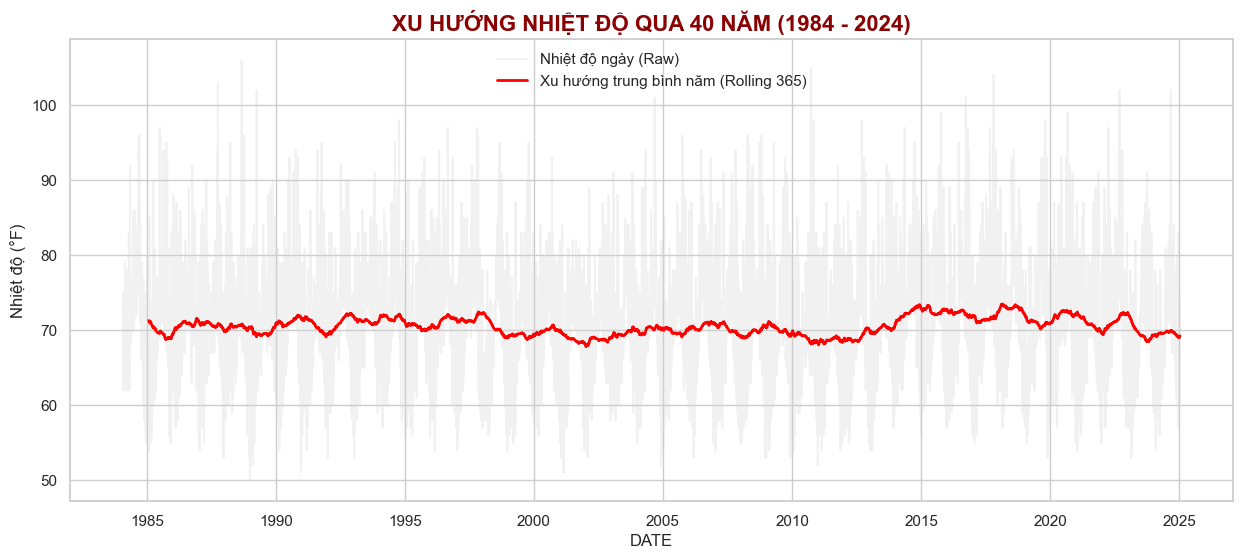

>> NHẬN XÉT: Hãy nhìn đường màu đỏ. Nếu nó đi lên -> Có xu hướng nóng lên toàn cầu.


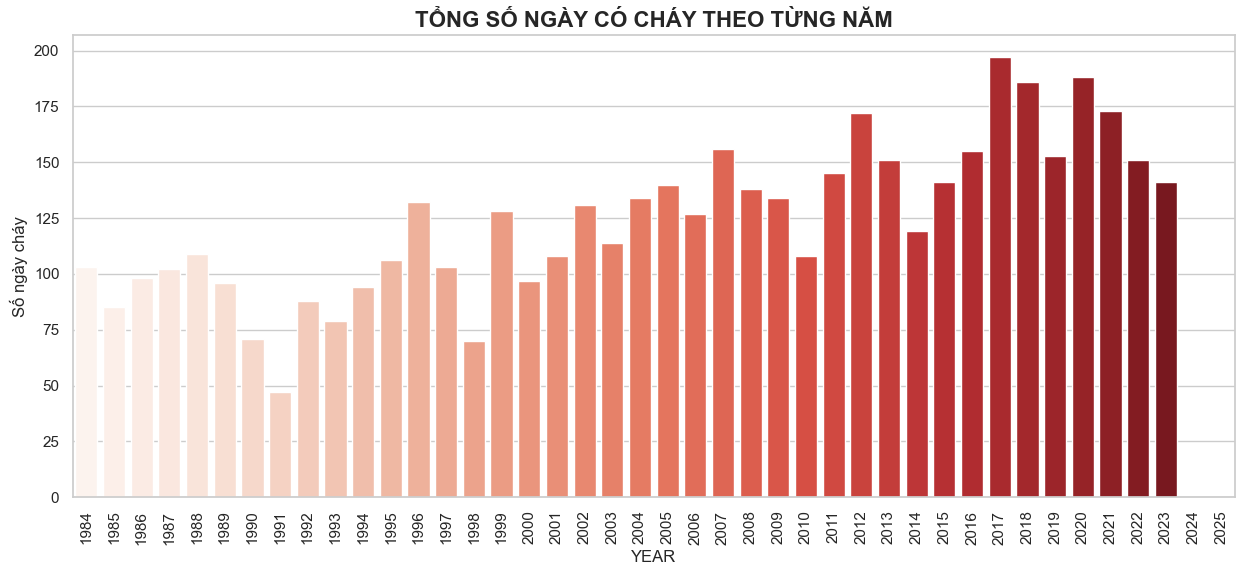

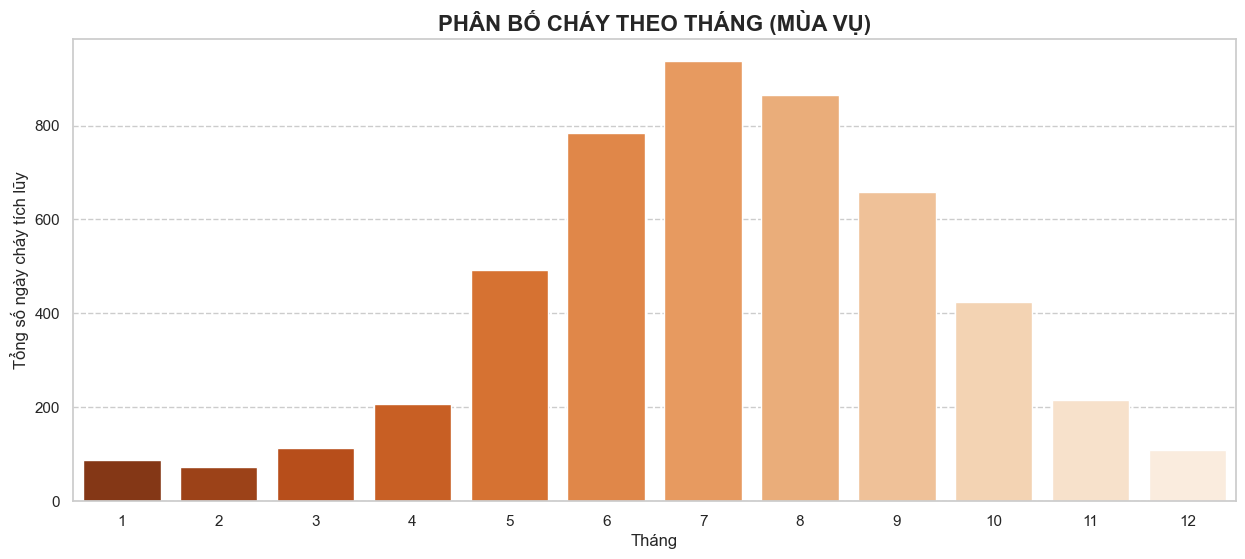

>> NHẬN XÉT MÙA VỤ: Các cột cao nhất chính là 'Mùa Cháy'.
   Dữ liệu này gợi ý ta nên tạo feature 'IS_FIRE_SEASON' cho các tháng đó.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print_section("3. EDA: PHÂN TÍCH XU HƯỚNG & CHUỖI THỜI GIAN (TIME SERIES)")

# Cài đặt giao diện biểu đồ cho đẹp
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)

# ==============================================================================
# BIỂU ĐỒ 1: KIỂM TRA XU HƯỚNG NHIỆT ĐỘ (GLOBAL WARMING CHECK)
# Dùng Rolling Mean (Trung bình trượt) 365 ngày để làm mượt đường biểu diễn
# ==============================================================================
plt.figure()
# Vẽ dữ liệu gốc (mờ nhạt để làm nền)
sns.lineplot(data=df, x="DATE", y="MAX_TEMP", color="lightgray", alpha=0.3, label="Nhiệt độ ngày (Raw)")

# Vẽ đường xu hướng (Làm mượt 365 ngày - Tức là trung bình 1 năm)
# Giúp loại bỏ dao động mùa vụ để nhìn thấy xu hướng dài hạn
df["TEMP_TREND_365"] = df["MAX_TEMP"].rolling(window=365).mean()
sns.lineplot(data=df, x="DATE", y="TEMP_TREND_365", color="red", linewidth=2, label="Xu hướng trung bình năm (Rolling 365)")

plt.title("XU HƯỚNG NHIỆT ĐỘ QUA 40 NĂM (1984 - 2024)", fontsize=16, fontweight='bold', color='darkred')
plt.ylabel("Nhiệt độ (°F)")
plt.legend()
plt.show()

print(">> NHẬN XÉT: Hãy nhìn đường màu đỏ. Nếu nó đi lên -> Có xu hướng nóng lên toàn cầu.")

# ==============================================================================
# BIỂU ĐỒ 2: TỔNG SỐ VỤ CHÁY THEO NĂM (YEARLY TREND)
# Kiểm tra xem tần suất cháy có tăng lên không
# ==============================================================================
# Gom nhóm theo năm và đếm số ngày có cháy
yearly_fire = df.groupby("YEAR")["FIRE_LABEL"].sum().reset_index()

plt.figure()
sns.barplot(data=yearly_fire, x="YEAR", y="FIRE_LABEL", palette="Reds")
plt.title("TỔNG SỐ NGÀY CÓ CHÁY THEO TỪNG NĂM", fontsize=16, fontweight='bold')
plt.xticks(rotation=90) # Xoay năm dọc xuống cho dễ đọc
plt.ylabel("Số ngày cháy")
plt.show()

# ==============================================================================
# BIỂU ĐỒ 3: TÍNH MÙA VỤ (SEASONALITY) - THÁNG NÀO NGUY HIỂM NHẤT?
# ==============================================================================
# Gom nhóm theo tháng và tính tổng số vụ cháy
monthly_fire = df.groupby("MONTH")["FIRE_LABEL"].sum().reset_index()

plt.figure()
sns.barplot(data=monthly_fire, x="MONTH", y="FIRE_LABEL", palette="Oranges_r")
plt.title("PHÂN BỐ CHÁY THEO THÁNG (MÙA VỤ)", fontsize=16, fontweight='bold')
plt.xlabel("Tháng")
plt.ylabel("Tổng số ngày cháy tích lũy")
plt.grid(axis='y', linestyle='--')
plt.show()

print(">> NHẬN XÉT MÙA VỤ: Các cột cao nhất chính là 'Mùa Cháy'.") 
print("   Dữ liệu này gợi ý ta nên tạo feature 'IS_FIRE_SEASON' cho các tháng đó.")

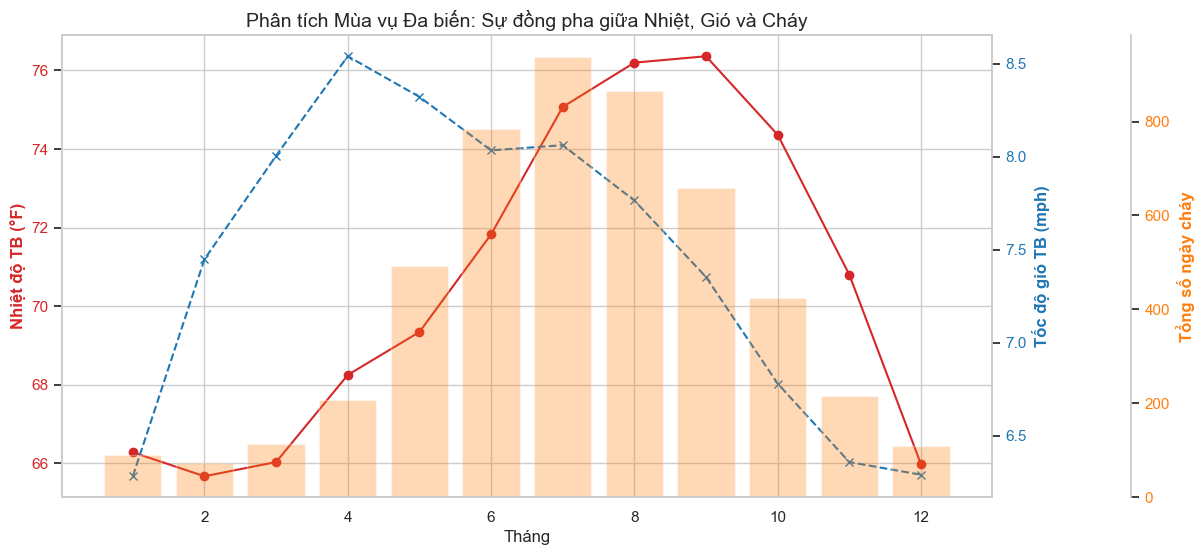

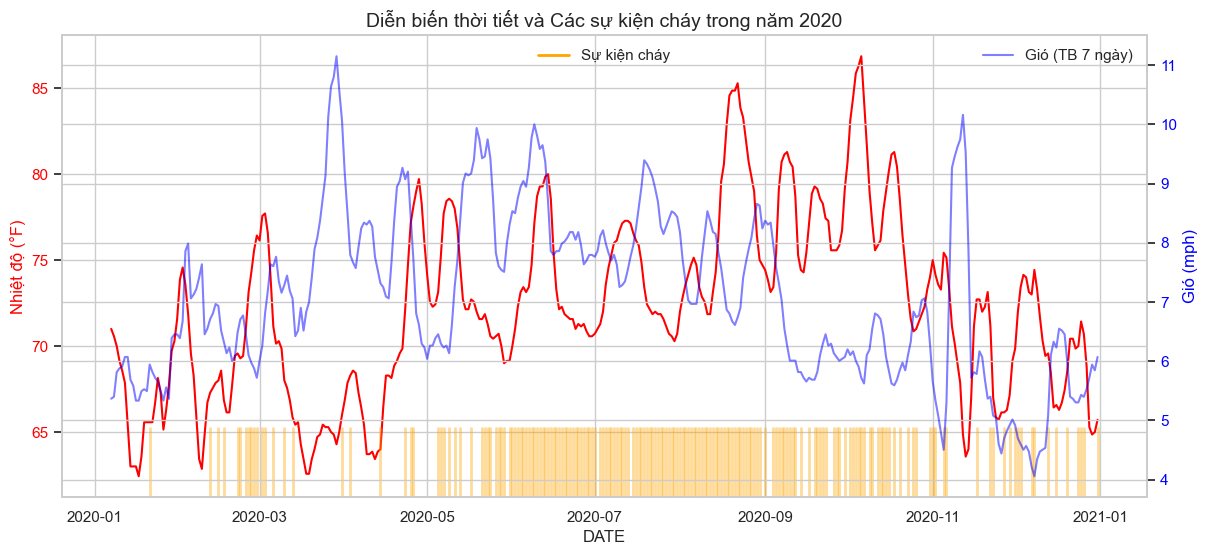

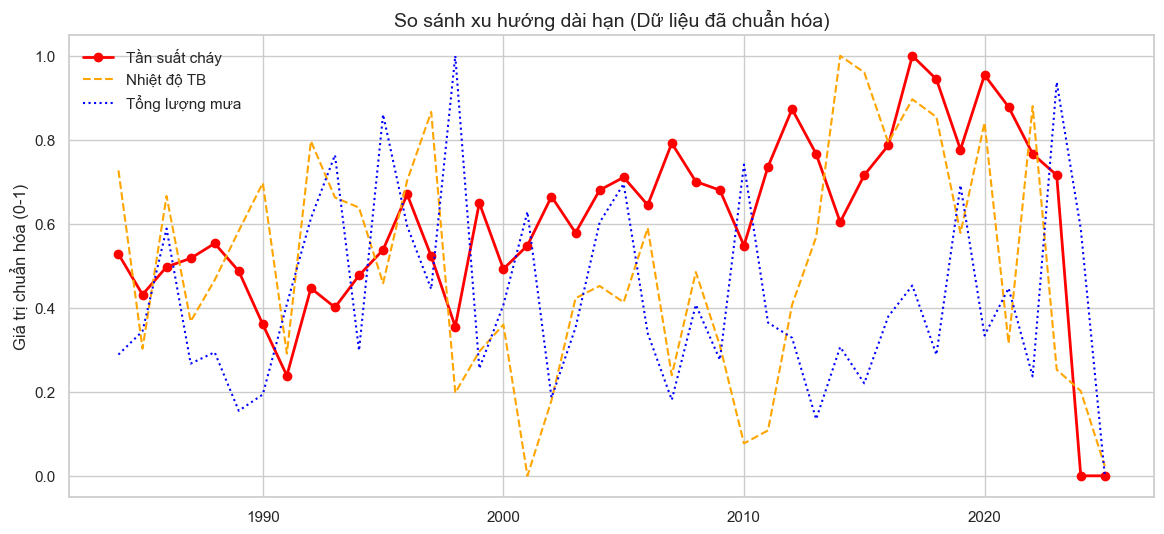

In [13]:


from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv(DATA_PATH)
df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df['DATE'].dt.year
df['Month'] = df['DATE'].dt.month

sns.set(style="whitegrid")

# --- BIỂU ĐỒ 1: Mùa vụ Đa biến (3 Trục Y) ---
# Gom nhóm theo tháng
monthly_stats = df.groupby('Month').agg({
    'MAX_TEMP': 'mean',
    'AVG_WIND_SPEED': 'mean',
    'FIRE_START_DAY': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục 1: Nhiệt độ (Đường đỏ)
color = 'tab:red'
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Nhiệt độ TB (°F)', color=color, fontweight='bold')
ax1.plot(monthly_stats['Month'], monthly_stats['MAX_TEMP'], color=color, marker='o', label='Nhiệt độ')
ax1.tick_params(axis='y', labelcolor=color)

# Trục 2: Gió (Đường xanh)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Tốc độ gió TB (mph)', color=color, fontweight='bold')
ax2.plot(monthly_stats['Month'], monthly_stats['AVG_WIND_SPEED'], color=color, marker='x', linestyle='--', label='Gió')
ax2.tick_params(axis='y', labelcolor=color)

# Trục 3: Số ngày cháy (Cột cam) - Dùng kỹ thuật "offset spine"
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.15)) # Đẩy trục thứ 3 ra xa một chút
ax3.set_ylabel('Tổng số ngày cháy', color='tab:orange', fontweight='bold')
ax3.bar(monthly_stats['Month'], monthly_stats['FIRE_START_DAY'], color='tab:orange', alpha=0.3, label='Ngày cháy')
ax3.tick_params(axis='y', labelcolor='tab:orange')
# Ẩn lưới cho trục phụ để đỡ rối
ax2.grid(False)
ax3.grid(False)

plt.title('Phân tích Mùa vụ Đa biến: Sự đồng pha giữa Nhiệt, Gió và Cháy', fontsize=14)
plt.show()


# --- BIỂU ĐỒ 2: Chi tiết chuỗi thời gian năm điển hình (Ví dụ: 2020) ---
year_zoom = 2020
df_sub = df[df['Year'] == year_zoom].sort_values('DATE').set_index('DATE')

# Tính trung bình trượt 7 ngày (Rolling Average) để làm mượt biểu đồ
df_sub['Roll_Temp'] = df_sub['MAX_TEMP'].rolling(window=7).mean()
df_sub['Roll_Wind'] = df_sub['AVG_WIND_SPEED'].rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Vẽ Nhiệt độ và Gió trên 2 trục
sns.lineplot(data=df_sub, x=df_sub.index, y='Roll_Temp', color='red', label='Nhiệt độ (TB 7 ngày)', ax=ax)
ax.set_ylabel('Nhiệt độ (°F)', color='red')
ax.tick_params(axis='y', labelcolor='red')

ax2 = ax.twinx()
sns.lineplot(data=df_sub, x=df_sub.index, y='Roll_Wind', color='blue', label='Gió (TB 7 ngày)', ax=ax2, alpha=0.5)
ax2.set_ylabel('Gió (mph)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Đánh dấu các ngày CÓ CHÁY (Vạch màu cam dưới đáy)
fire_dates = df_sub[df_sub['FIRE_START_DAY'] == True].index
for date in fire_dates:
    ax.axvline(date, color='orange', alpha=0.4, ymin=0, ymax=0.15, linewidth=2)

plt.title(f'Diễn biến thời tiết và Các sự kiện cháy trong năm {year_zoom}', fontsize=14)
# Tạo chú thích giả cho sự kiện cháy
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='orange', lw=2)]
ax.legend(custom_lines, ['Sự kiện cháy'], loc='upper center')
plt.show()


# --- BIỂU ĐỒ 3: Xu hướng dài hạn (Chuẩn hóa Min-Max) ---
# Gom nhóm theo năm
yearly_stats = df.groupby('Year').agg({
    'MAX_TEMP': 'mean',
    'PRECIPITATION': 'sum',
    'FIRE_START_DAY': 'sum'
}).reset_index()

# Chuẩn hóa dữ liệu về khoảng [0, 1] để so sánh xu hướng
scaler = MinMaxScaler()
cols = ['MAX_TEMP', 'PRECIPITATION', 'FIRE_START_DAY']
yearly_norm = yearly_stats.copy()
yearly_norm[cols] = scaler.fit_transform(yearly_norm[cols])

plt.figure(figsize=(14, 6))
plt.plot(yearly_norm['Year'], yearly_norm['FIRE_START_DAY'], marker='o', color='red', linewidth=2, label='Tần suất cháy')
plt.plot(yearly_norm['Year'], yearly_norm['MAX_TEMP'], linestyle='--', color='orange', label='Nhiệt độ TB')
plt.plot(yearly_norm['Year'], yearly_norm['PRECIPITATION'], linestyle=':', color='blue', label='Tổng lượng mưa')

plt.title('So sánh xu hướng dài hạn (Dữ liệu đã chuẩn hóa)', fontsize=14)
plt.ylabel('Giá trị chuẩn hóa (0-1)')
plt.legend()
plt.show()

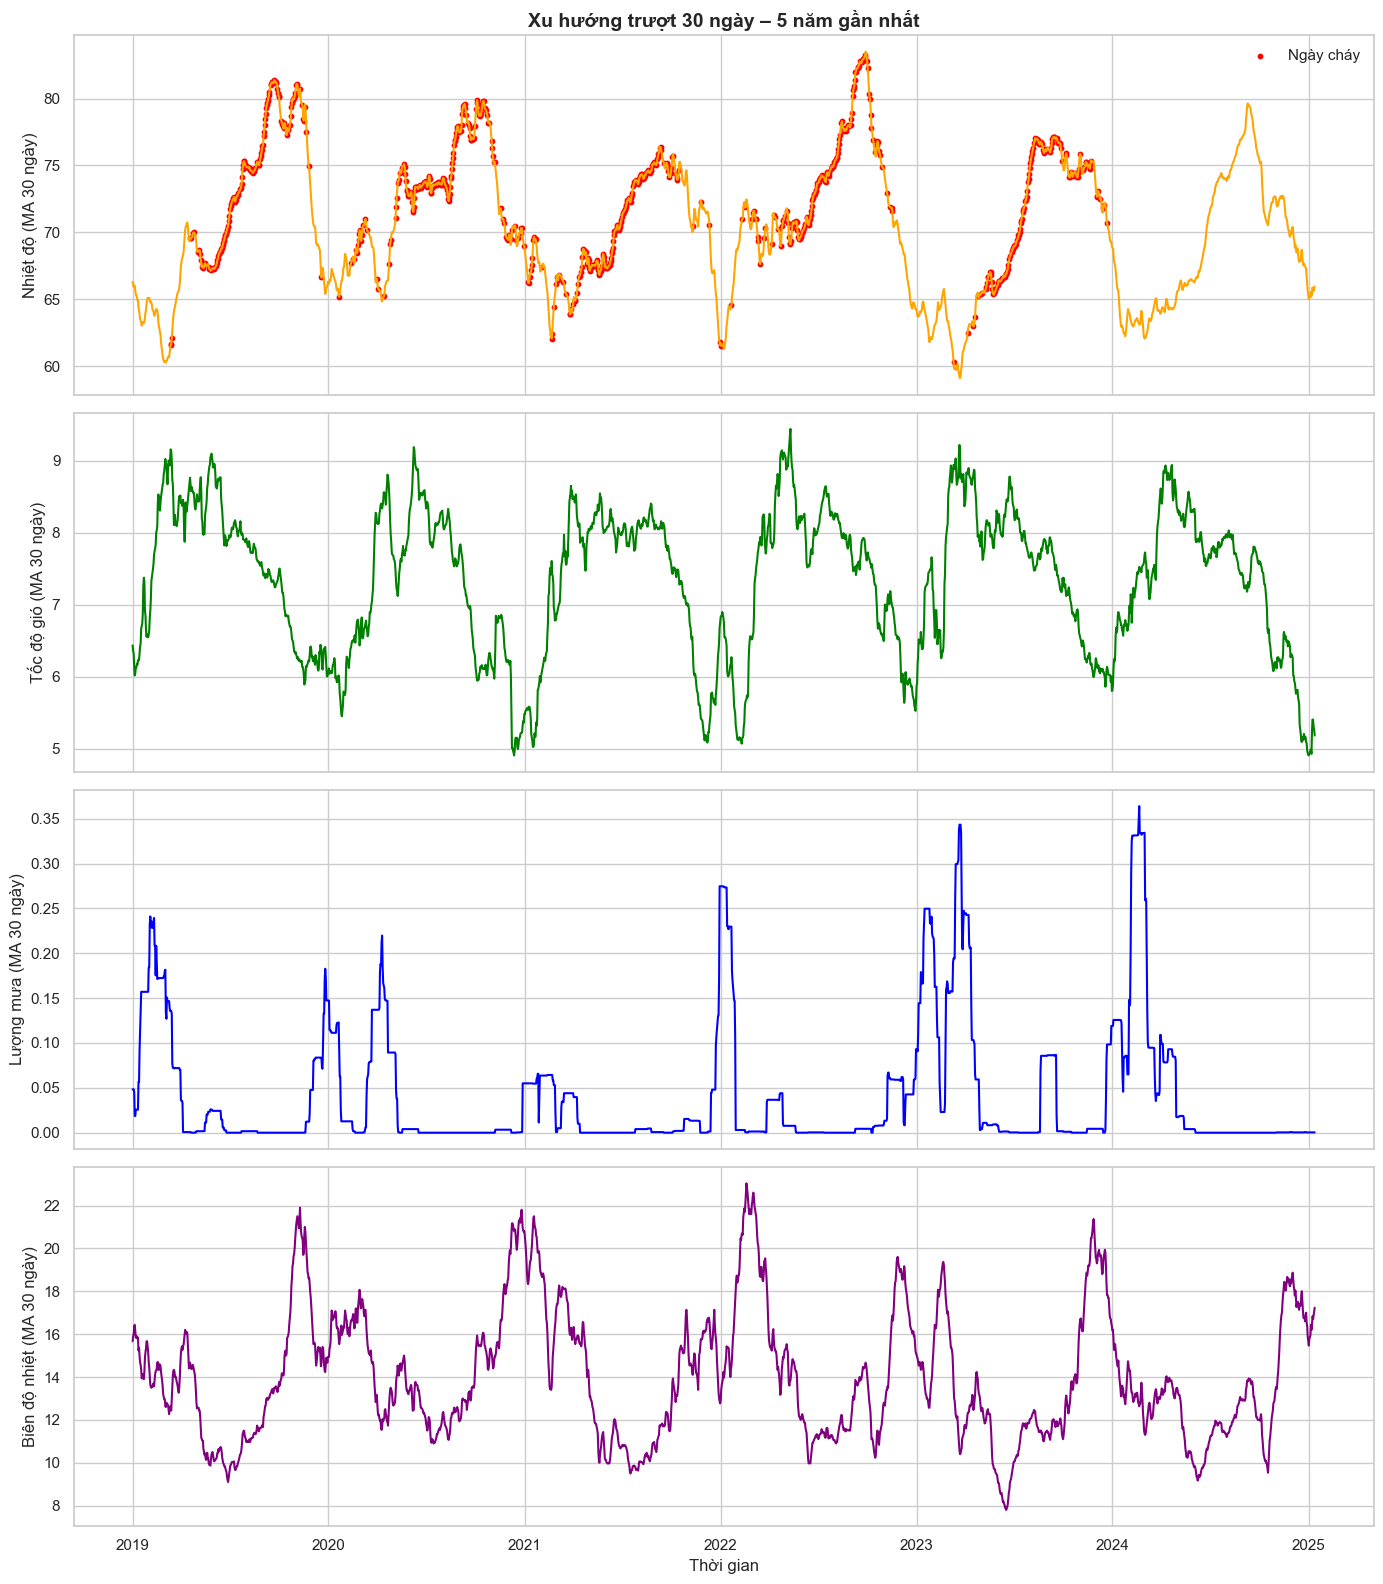

Multivariate time-series charts with TEMP_RANGE generated.


In [14]:

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.set_index('DATE').sort_index()

# Rolling average 30 ngày
df['Temp_Rolling'] = df['MAX_TEMP'].rolling(window=30).mean()
df['Wind_Rolling'] = df['AVG_WIND_SPEED'].rolling(window=30).mean()
df['Precip_Rolling'] = df['PRECIPITATION'].rolling(window=30).mean()

# ===== THAY ĐỘ ẨM BẰNG BIÊN ĐỘ NHIỆT =====
df['TempRange_Rolling'] = df['TEMP_RANGE'].rolling(window=30).mean()

# Lọc 5 năm gần nhất
df_recent = df[df.index.year >= 2019]

# ===== VẼ BIỂU ĐỒ =====
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# --- Nhiệt độ ---
ax1.plot(df_recent.index, df_recent['Temp_Rolling'], color='orange')
ax1.set_ylabel('Nhiệt độ (MA 30 ngày)')
ax1.set_title(
    'Xu hướng trượt 30 ngày – 5 năm gần nhất',
    fontsize=14, fontweight='bold'
)

fire_days = df_recent[df_recent['FIRE_START_DAY'] == True].index
ax1.scatter(
    fire_days,
    df_recent.loc[fire_days, 'Temp_Rolling'],
    color='red', s=10, label='Ngày cháy'
)
ax1.legend()

# --- Gió ---
ax2.plot(df_recent.index, df_recent['Wind_Rolling'], color='green')
ax2.set_ylabel('Tốc độ gió (MA 30 ngày)')

# --- Mưa ---
ax3.plot(df_recent.index, df_recent['Precip_Rolling'], color='blue')
ax3.set_ylabel('Lượng mưa (MA 30 ngày)')

# --- Biên độ nhiệt ---
ax4.plot(df_recent.index, df_recent['TempRange_Rolling'], color='purple')
ax4.set_ylabel('Biên độ nhiệt (MA 30 ngày)')
ax4.set_xlabel('Thời gian')

plt.tight_layout()
plt.savefig('rolling_trends_with_temp_range.png')
plt.show()

print("Multivariate time-series charts with TEMP_RANGE generated.")


Dataset shape after preprocessing: (14981, 9)


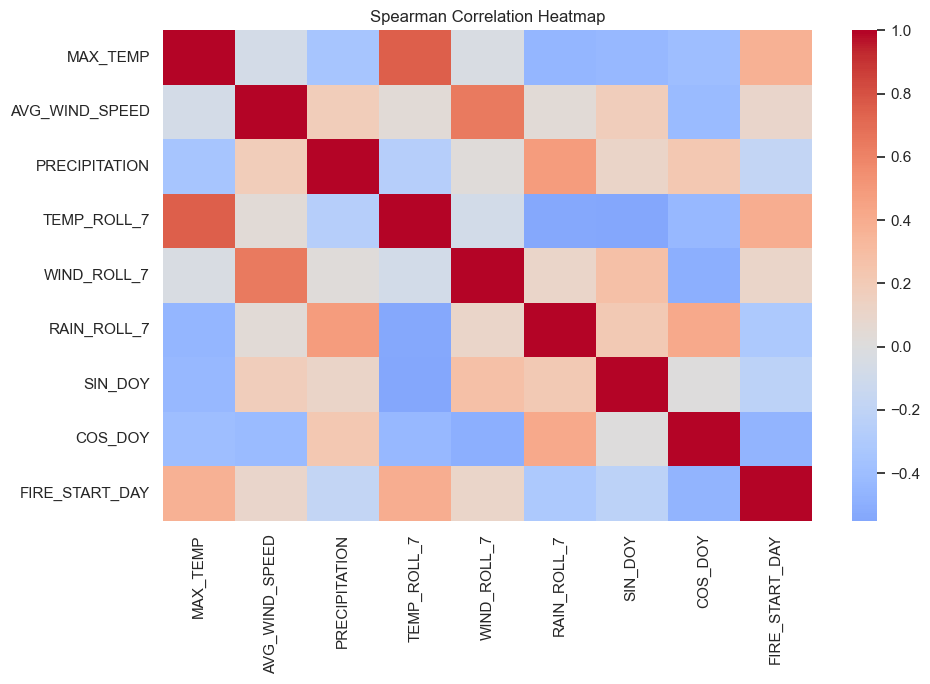


Spearman correlation with FIRE_START_DAY:
COS_DOY          -0.471024
TEMP_ROLL_7       0.388275
MAX_TEMP          0.372648
RAIN_ROLL_7      -0.317783
SIN_DOY          -0.218031
PRECIPITATION    -0.178103
WIND_ROLL_7       0.105710
AVG_WIND_SPEED    0.094235
Name: FIRE_START_DAY, dtype: float64


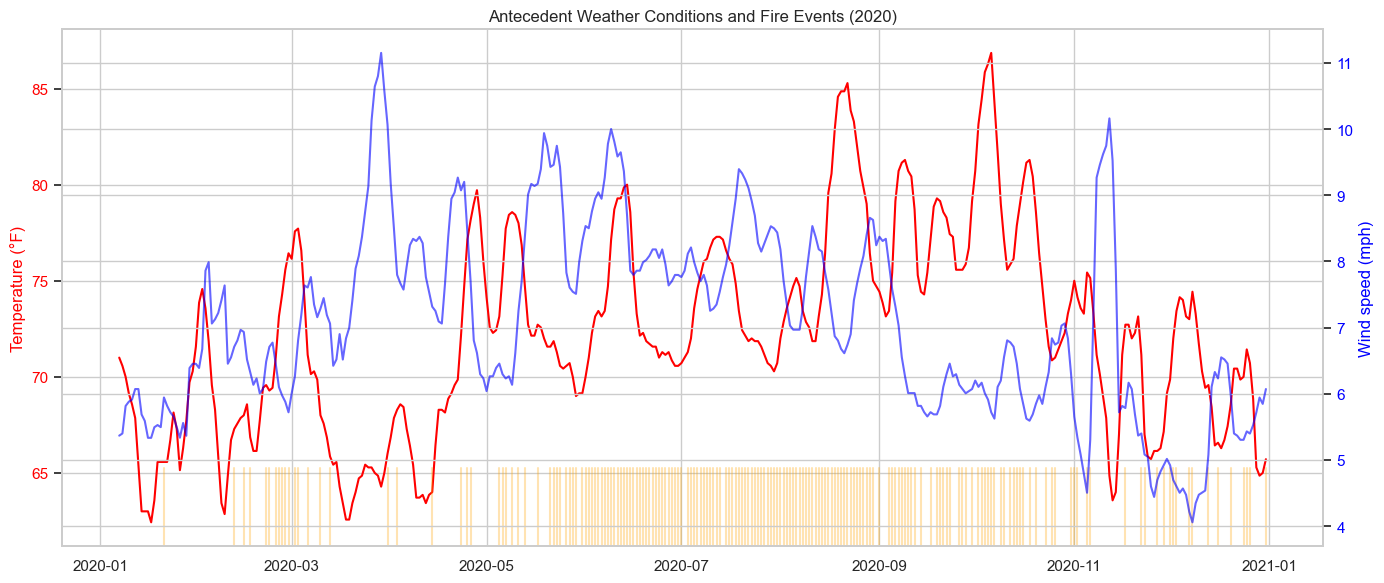


Final selected features:
 - RAIN_ROLL_7
 - TEMP_ROLL_7
 - WIND_ROLL_7
 - MAX_TEMP
 - SIN_DOY
 - COS_DOY

Final ML dataset shape: (14981, 6)


In [15]:
df.reset_index(inplace=True)  # Reset index to make DATE a column again

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').set_index('DATE')

TARGET = 'FIRE_START_DAY'

# ======================
# 2. TIME & SEASONAL FEATURES
# ======================
df['DAY_OF_YEAR'] = df.index.dayofyear
df['SIN_DOY'] = np.sin(2 * np.pi * df['DAY_OF_YEAR'] / 365)
df['COS_DOY'] = np.cos(2 * np.pi * df['DAY_OF_YEAR'] / 365)

# ======================
# 3. ROLLING FEATURES (7 DAYS – ANTECEDENT CONDITIONS)
# ======================
df['TEMP_ROLL_7']  = df['MAX_TEMP'].rolling(7).mean()
df['WIND_ROLL_7']  = df['AVG_WIND_SPEED'].rolling(7).mean()
df['RAIN_ROLL_7']  = df['PRECIPITATION'].rolling(7).sum()

# ======================
# 4. REMOVE NON-INFORMATIVE FEATURES
# ======================
DROP_COLS = ['STATION_ID', 'LAT', 'LON']
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# ======================
# 5. AVOID DATA LEAKAGE (SHIFT)
# ======================
FEATURES_EDA = [
    'MAX_TEMP',
    'AVG_WIND_SPEED',
    'PRECIPITATION',
    'TEMP_ROLL_7',
    'WIND_ROLL_7',
    'RAIN_ROLL_7',
    'SIN_DOY',
    'COS_DOY'
]

X = df[FEATURES_EDA].shift(1)
y = df[TARGET]

data = pd.concat([X, y], axis=1).dropna()

print("Dataset shape after preprocessing:", data.shape)

# =====================================================
# 6. ML-EDA STEP 1: HEATMAP (SPEARMAN)
# =====================================================
corr = data.corr(method='spearman')

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=False
)
plt.title('Spearman Correlation Heatmap')
plt.tight_layout()
plt.show()

# Correlation with target
corr_target = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

print("\nSpearman correlation with FIRE_START_DAY:")
print(corr_target)

# =====================================================
# 7. ML-EDA STEP 2: TIME SERIES ANALYSIS (EXAMPLE YEAR)
# =====================================================
YEAR_EXAMPLE = 2020
df_year = df[df.index.year == YEAR_EXAMPLE]

df_year['TEMP_ROLL_7'] = df_year['MAX_TEMP'].rolling(7).mean()
df_year['WIND_ROLL_7'] = df_year['AVG_WIND_SPEED'].rolling(7).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    df_year.index,
    df_year['TEMP_ROLL_7'],
    color='red',
    label='Temperature (7-day mean)'
)
ax1.set_ylabel('Temperature (°F)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(
    df_year.index,
    df_year['WIND_ROLL_7'],
    color='blue',
    alpha=0.6,
    label='Wind speed (7-day mean)'
)
ax2.set_ylabel('Wind speed (mph)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Fire events
fire_days = df_year[df_year[TARGET] == 1].index
for d in fire_days:
    ax1.axvline(d, color='orange', alpha=0.3, ymin=0, ymax=0.15)

plt.title(f'Antecedent Weather Conditions and Fire Events ({YEAR_EXAMPLE})')
plt.tight_layout()
plt.show()

# =====================================================
# 8. FINAL FEATURE SELECTION (FROM ML-EDA)
# =====================================================
FINAL_FEATURES = [
    'RAIN_ROLL_7',     # Fuel dryness
    'TEMP_ROLL_7',     # Heat persistence
    'WIND_ROLL_7',     # Fire spread
    'MAX_TEMP',        # Extreme heat signal
    'SIN_DOY',         # Seasonality
    'COS_DOY'
]

X_final = data[FINAL_FEATURES]
y_final = data[TARGET]

print("\nFinal selected features:")
for f in FINAL_FEATURES:
    print(" -", f)

print("\nFinal ML dataset shape:", X_final.shape)

so sánh feature và đưa ra feature

In [16]:
TARGET = 'FIRE_START_DAY'
CORR_THRESHOLD = 0.05

FEATURES_EDA = [
    'MAX_TEMP',
    'AVG_WIND_SPEED',
    'PRECIPITATION',
    'TEMP_ROLL_7',
    'WIND_ROLL_7',
    'RAIN_ROLL_7',
    'SIN_DOY',
    'COS_DOY'
]

# ---- Tạo lại dataset an toàn leakage ----
X = df[FEATURES_EDA].shift(1)
y = df[TARGET]
data = pd.concat([X, y], axis=1).dropna()

# ---- Tính Spearman correlation ----
corr = data.corr(method='spearman')
corr_target = corr[TARGET].drop(TARGET)

# ---- Feature được chọn theo correlation ----
features_by_corr = {
    f for f in FEATURES_EDA
    if abs(corr_target[f]) >= CORR_THRESHOLD
}

# ---- So sánh ----
eda_features = set(FEATURES_EDA)

features_giu_lai = sorted(eda_features & features_by_corr)
features_loai_bo = sorted(eda_features - features_by_corr)

# ---- HIỂN THỊ SO SÁNH (TIẾNG VIỆT) ----
print("\n===== SO SÁNH ĐẶC TRƯNG =====")

print("\n📌 Danh sách feature ban đầu (EDA):")
for f in FEATURES_EDA:
    print(" -", f)

print("\n✅ feature được GIỮ LẠI sau ML-EDA:")
for f in features_giu_lai:
    print(" -", f)

print("\n❌ feature bị LOẠI BỎ (tương quan yếu với FIRE_START_DAY):")
for f in features_loai_bo:
    print(" -", f)

# ---- LIST FEATURE CUỐI ----
FINAL_FEATURES = features_giu_lai

print("\n🔥 DANH SÁCH feature CUỐI CÙNG (DÙNG CHO MODEL):")
print(FINAL_FEATURES)



===== SO SÁNH ĐẶC TRƯNG =====

📌 Danh sách feature ban đầu (EDA):
 - MAX_TEMP
 - AVG_WIND_SPEED
 - PRECIPITATION
 - TEMP_ROLL_7
 - WIND_ROLL_7
 - RAIN_ROLL_7
 - SIN_DOY
 - COS_DOY

✅ feature được GIỮ LẠI sau ML-EDA:
 - AVG_WIND_SPEED
 - COS_DOY
 - MAX_TEMP
 - PRECIPITATION
 - RAIN_ROLL_7
 - SIN_DOY
 - TEMP_ROLL_7
 - WIND_ROLL_7

❌ feature bị LOẠI BỎ (tương quan yếu với FIRE_START_DAY):

🔥 DANH SÁCH feature CUỐI CÙNG (DÙNG CHO MODEL):
['AVG_WIND_SPEED', 'COS_DOY', 'MAX_TEMP', 'PRECIPITATION', 'RAIN_ROLL_7', 'SIN_DOY', 'TEMP_ROLL_7', 'WIND_ROLL_7']


## PHẦN MÔ HÌNH HOÁ (Train/Test chuẩn chuỗi thời gian + 5 mô hình + Feature importance + Stepwise)


In [17]:
print_section("4. CHUẨN BỊ DATASET CHO MÔ HÌNH (NO LEAKAGE)")

# ============================
# 1) LIST FEATURE TỪ EDA
# ============================
# FINAL_FEATURES ở cell trước là list feature đã "lọc" theo ML-EDA (Spearman)
LIST_FEATURES_EDA = list(FINAL_FEATURES)  # giữ nguyên list để đưa vào stepwise sau

print("LIST_FEATURES_EDA:", LIST_FEATURES_EDA)

# ============================
# 2) TẠO FEATURE POOL CHO ML
# ============================
# Mục tiêu: để ML tự học và tự chọn feature quan trọng (không chỉ bó hẹp trong LIST_FEATURES_EDA)
# Nhưng cần CHẶN LEAKAGE: loại bỏ các cột liên quan trực tiếp đến FIRE/label (trừ target)
TARGET = 'FIRE_START_DAY'  # đảm bảo nhất quán
LEAKY_KEYWORDS = ["FIRE", "LABEL", "BURN", "ACRE", "AREA"]  # Để loại những cột có nguy cơ “leakage” (rò rỉ thông tin mục tiêu) ra khỏi feature_pool.

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_pool = []
for c in numeric_cols:
    if c == TARGET:
        continue
    name_up = str(c).upper()
    if any(k in name_up for k in LEAKY_KEYWORDS) and c != TARGET:
        # loại bỏ các cột "hậu nghiệm" của cháy rừng (dễ leak)
        continue
    feature_pool.append(c)

# Bảo đảm EDA feature nằm trong pool (nếu có)
for f in LIST_FEATURES_EDA:
    if f in df.columns and f not in feature_pool and f != TARGET:
        feature_pool.append(f)

feature_pool = sorted(feature_pool)

print("Số feature trong feature_pool (ML):", len(feature_pool))
print("feature trong csv:", feature_pool)

# ============================
# 3) TẠO DATASET ML AN TOÀN LEAKAGE
# ============================
X_all = df[feature_pool].shift(1)   # SHIFT(1) => chỉ dùng thông tin quá khứ
y_all = df[TARGET].astype(int)

data_ml = pd.concat([X_all, y_all], axis=1).dropna()

X_ml = data_ml.drop(columns=[TARGET])
y_ml = data_ml[TARGET]

print("ML dataset shape:", X_ml.shape)
print("Target distribution:\n", y_ml.value_counts())


4. CHUẨN BỊ DATASET CHO MÔ HÌNH (NO LEAKAGE)

LIST_FEATURES_EDA: ['AVG_WIND_SPEED', 'COS_DOY', 'MAX_TEMP', 'PRECIPITATION', 'RAIN_ROLL_7', 'SIN_DOY', 'TEMP_ROLL_7', 'WIND_ROLL_7']
Số feature trong feature_pool (ML): 22
feature trong csv: ['AVG_WIND_SPEED', 'COS_DOY', 'DAY_OF_YEAR', 'LAGGED_AVG_WIND_SPEED', 'LAGGED_PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'MONTH', 'Month', 'PRECIPITATION', 'Precip_Rolling', 'RAIN_ROLL_7', 'SIN_DOY', 'TEMP_RANGE', 'TEMP_ROLL_7', 'TempRange_Rolling', 'Temp_Rolling', 'WIND_ROLL_7', 'WIND_TEMP_RATIO', 'Wind_Rolling', 'YEAR', 'Year']
ML dataset shape: (14958, 22)
Target distribution:
 FIRE_START_DAY
0    9988
1    4970
Name: count, dtype: int64


## Cell 11 – Chia Train/Test theo chuỗi thời gian + TimeSeriesSplit 

In [18]:
print_section("5. CHIA TRAIN/TEST THEO TIME SERIES + TSCV")

# Chia holdout: lấy đoạn CUỐI chuỗi làm test (đúng bản chất dự báo tương lai)
TEST_SIZE = 0.2
n = len(X_ml)
split_idx = int(n * (1 - TEST_SIZE))

X_train, X_test = X_ml.iloc[:split_idx].copy(), X_ml.iloc[split_idx:].copy()
y_train, y_test = y_ml.iloc[:split_idx].copy(), y_ml.iloc[split_idx:].copy()

print("Train:", X_train.shape, "Test:", X_test.shape)

# TimeSeriesSplit: walk-forward CV
# gap giúp tránh "dính" các điểm quá gần nhau (có thể set gap=7 nếu muốn nghiêm ngặt hơn)
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5, gap=0)  # gap=0 là đủ khi đã shift(1); muốn chặt hơn thì đặt gap=7
print("TimeSeriesSplit:", tscv)

# Tính scale_pos_weight (hữu ích cho XGBoost/LightGBM/CatBoost khi mất cân bằng)
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = float(neg / max(pos, 1))
print("scale_pos_weight:", scale_pos_weight)


5. CHIA TRAIN/TEST THEO TIME SERIES + TSCV

Train: (11966, 22) Test: (2992, 22)
TimeSeriesSplit: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)
scale_pos_weight: 2.172322375397667


## Cell 12 – Huấn luyện 5 mô hình (time-series features)

In [19]:
print_section("6. HUẤN LUYỆN 5 MÔ HÌNH (TIME-SERIES FEATURES) + TUNING")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# ---------------------------
# Helper: threshold tuning (tối ưu F1 trên holdout)
# ---------------------------
def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 91):
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t), float(best_f1)

def evaluate_model(name, model, Xte, yte):
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(Xte)[:, 1]
    else:
        # fallback: decision_function -> sigmoid
        dec = model.decision_function(Xte)
        prob = 1 / (1 + np.exp(-dec))

    t, bestf1 = find_best_threshold(yte, prob)
    pred = (prob >= t).astype(int)

    return {
        "model": name,
        "threshold*": t,
        "accuracy": accuracy_score(yte, pred),
        "precision": precision_score(yte, pred, zero_division=0),
        "recall": recall_score(yte, pred, zero_division=0),
        "f1": f1_score(yte, pred, zero_division=0),
        "roc_auc": roc_auc_score(yte, prob) if len(np.unique(yte)) == 2 else np.nan
    }

# ---------------------------
# 1) Logistic Regression (baseline mạnh + giải thích tốt)
# ---------------------------
logreg_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="saga",
        penalty="l2",
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

logreg_params = {
    "clf__C": np.logspace(-3, 2, 20)
}

# ---------------------------
# 2) RandomForest (ổn định, bắt non-linearity)
# ---------------------------
rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=600,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_params = {
    "clf__max_depth": [None, 6, 10, 14, 18],
    "clf__min_samples_leaf": [1, 2, 4, 8],
    "clf__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8]
}

# ---------------------------
# 3) XGBoost / 4) LightGBM / 5) CatBoost (nếu có)
# Nếu máy bạn thiếu thư viện thì code sẽ tự bỏ qua mô hình đó.
# ---------------------------
models = {
    "LogReg": (logreg_pipe, logreg_params),
    "RandomForest": (rf, rf_params)
}

# XGBClassifier: eval_metric nên set trong __init__ (theo docs xgboost >= 1.6) 
try:
    from xgboost import XGBClassifier
    xgb = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=600,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight
        ))
    ])
    xgb_params = {
        "clf__max_depth": [3, 4, 5, 6, 8],
        "clf__learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15],
        "clf__subsample": [0.6, 0.8, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0],
        "clf__min_child_weight": [1, 3, 5, 8],
        "clf__reg_lambda": [0.5, 1.0, 2.0, 5.0]
    }
    models["XGBoost"] = (xgb, xgb_params)
except Exception as e:
    print("⚠️ Không dùng được XGBoost:", e)

# LightGBM: binary imbalanced nên ưu tiên scale_pos_weight / is_unbalance hơn class_weight 
try:
    from lightgbm import LGBMClassifier
    lgbm = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", LGBMClassifier(
            objective="binary",
            n_estimators=1200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight
        ))
    ])
    lgbm_params = {
        "clf__learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
        "clf__num_leaves": [15, 31, 63, 127],
        "clf__max_depth": [-1, 3, 5, 7, 9],
        "clf__subsample": [0.6, 0.8, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0],
        "clf__min_child_samples": [10, 20, 40, 80]
    }
    models["LightGBM"] = (lgbm, lgbm_params)
except Exception as e:
    print("⚠️ Không dùng được LightGBM:", e)

# CatBoost: có scale_pos_weight, auto_class_weights, class_weights (không dùng đồng thời) 
try:
    from catboost import CatBoostClassifier
    cat = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=1200,
            depth=6,
            learning_rate=0.05,
            random_seed=RANDOM_STATE,
            verbose=False,
            thread_count=-1,
            scale_pos_weight=scale_pos_weight
        ))
    ])
    cat_params = {
        "clf__depth": [4, 5, 6, 7, 8, 10],
        "clf__learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
        "clf__l2_leaf_reg": [1, 3, 5, 7, 9, 12],
        "clf__iterations": [600, 1000, 1600]
    }
    models["CatBoost"] = (cat, cat_params)
except Exception as e:
    print("⚠️ Không dùng được CatBoost:", e)

# ---------------------------
# RandomizedSearchCV (tuning nhẹ, vẫn hiệu quả)
# ---------------------------
N_ITER = 20   # tăng lên 40-80 nếu máy bạn khoẻ để model tốt hơn
best_models = {}
cv_scores = []

for name, (estimator, params) in models.items():
    print("\n--- Tuning:", name, "---")
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=params,
        n_iter=N_ITER,
        scoring="f1",
        cv=tscv,
        n_jobs=-1 if name != "CatBoost" else 1,  # CatBoost tự dùng thread_count
        verbose=1,
        random_state=RANDOM_STATE,
        refit=True
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    cv_scores.append({"model": name, "best_cv_f1": float(search.best_score_), "best_params": search.best_params_})
    print("Best CV F1:", search.best_score_)

cv_scores_df = pd.DataFrame(cv_scores).sort_values("best_cv_f1", ascending=False)
cv_scores_df


6. HUẤN LUYỆN 5 MÔ HÌNH (TIME-SERIES FEATURES) + TUNING


--- Tuning: LogReg ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1: 0.6672194728149463

--- Tuning: RandomForest ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1: 0.6762651976000059

--- Tuning: XGBoost ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1: 0.6541558810235817

--- Tuning: LightGBM ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 3772, number of negative: 8194
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3705
[LightGBM] [Info] Number of data points in the train set: 11966, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.315226 -> initscore=-0.775797
[LightGBM] [Info] Start training from score -0.775797
[Lig

,model,best_cv_f1,best_params
1,RandomForest,0.676265,"{'clf__min_samples_leaf': 4, 'clf__max_feature..."
4,CatBoost,0.667790,"{'clf__learning_rate': 0.02, 'clf__l2_leaf_reg..."
0,LogReg,0.667219,{'clf__C': 0.0018329807108324356}
2,XGBoost,0.654156,"{'clf__subsample': 0.8, 'clf__reg_lambda': 5.0..."
3,LightGBM,0.648123,"{'clf__subsample': 0.8, 'clf__num_leaves': 127..."


## Cell 13 – Đánh giá Holdout (test cuối chuỗi) + chọn mô hình tốt nhất

In [20]:
print_section("7. ĐÁNH GIÁ HOLDOUT (TEST CUỐI CHUỖI)")

holdout_reports = []
for name, model in best_models.items():
    rep = evaluate_model(name, model, X_test, y_test)
    holdout_reports.append(rep)

holdout_df = pd.DataFrame(holdout_reports).sort_values("f1", ascending=False)
holdout_df


7. ĐÁNH GIÁ HOLDOUT (TEST CUỐI CHUỖI)



,model,threshold*,accuracy,precision,recall,f1,roc_auc
1,RandomForest,0.37,0.734291,0.624153,0.845576,0.718185,0.819616
0,LogReg,0.54,0.735628,0.627746,0.834725,0.716589,0.814960
4,CatBoost,0.40,0.730949,0.622583,0.833055,0.712603,0.822591
3,LightGBM,0.42,0.727941,0.618665,0.835559,0.710938,0.817676
2,XGBoost,0.40,0.724599,0.614024,0.840568,0.709655,0.819415


## Cell 14 – Feature importance (Permutation) → list feature của từng mô hình + list union

In [21]:
print_section("8. FEATURE IMPORTANCE -> LIST FEATURE CHO MỖI MÔ HÌNH")

FEATURES_MODEL_DICT = {}   # {model_name: [top_features]}
IMPORTANCE_TABLES = {}     # {model_name: dataframe}

def permutation_top_features(model, Xte, yte, topk=25, n_repeats=10):
    r = permutation_importance(
        model, Xte, yte,
        scoring="f1",
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    imp = pd.DataFrame({
        "feature": Xte.columns,
        "importance": r.importances_mean
    }).sort_values("importance", ascending=False)
    return imp, imp.head(topk)["feature"].tolist()

for name, model in best_models.items():
    imp_df, top_feats = permutation_top_features(model, X_test, y_test, topk=30, n_repeats=10)
    IMPORTANCE_TABLES[name] = imp_df
    FEATURES_MODEL_DICT[name] = top_feats
    print(f"\n{name} - TOP features:")
    print(top_feats[:15])

FEATURES_MODEL_UNION = sorted(set().union(*FEATURES_MODEL_DICT.values()))
print("\nFEATURES_MODEL_UNION length:", len(FEATURES_MODEL_UNION))


8. FEATURE IMPORTANCE -> LIST FEATURE CHO MỖI MÔ HÌNH


LogReg - TOP features:
['COS_DOY', 'Precip_Rolling', 'TempRange_Rolling', 'MIN_TEMP', 'MAX_TEMP', 'TEMP_ROLL_7', 'Year', 'YEAR', 'RAIN_ROLL_7', 'LAGGED_PRECIPITATION', 'Temp_Rolling', 'PRECIPITATION', 'SIN_DOY', 'WIND_TEMP_RATIO', 'Wind_Rolling']

RandomForest - TOP features:
['COS_DOY', 'SIN_DOY', 'Temp_Rolling', 'TEMP_ROLL_7', 'Precip_Rolling', 'MAX_TEMP', 'LAGGED_AVG_WIND_SPEED', 'AVG_WIND_SPEED', 'PRECIPITATION', 'YEAR', 'Year', 'LAGGED_PRECIPITATION', 'WIND_TEMP_RATIO', 'WIND_ROLL_7', 'Wind_Rolling']

XGBoost - TOP features:
['COS_DOY', 'Precip_Rolling', 'SIN_DOY', 'DAY_OF_YEAR', 'TEMP_ROLL_7', 'MAX_TEMP', 'PRECIPITATION', 'WIND_ROLL_7', 'Month', 'MIN_TEMP', 'Year', 'YEAR', 'RAIN_ROLL_7', 'Temp_Rolling', 'TEMP_RANGE']

LightGBM - TOP features:
['COS_DOY', 'Precip_Rolling', 'SIN_DOY', 'MAX_TEMP', 'Temp_Rolling', 'TEMP_ROLL_7', 'DAY_OF_YEAR', 'TEMP_RANGE', 'WIND_ROLL_7', 'TempRange_Rolling', 'Wind_Rolling', 'LAGGED_AVG_WIND_SP

## Cell 15 – STEPWISE trên tập ứng viên = EDA ∪ MODEL

In [22]:
print_section("9. STEPWISE-> FEATURE CUỐI CÙNG")

# Candidate = union(EDA list, model union)
CANDIDATES = sorted(set(LIST_FEATURES_EDA).union(set(FEATURES_MODEL_UNION)))

# Giới hạn số biến để stepwise chạy sâu, không bị nổ thời gian (có thể tăng nếu muốn)
MAX_CANDIDATES = 80
CANDIDATES = CANDIDATES[:MAX_CANDIDATES]

print("Số candidate đưa vào stepwise:", len(CANDIDATES))
print("Danh sach candidate:", CANDIDATES)

# --- Stepwise bằng statsmodels Logit (binary) ---
try:
    import statsmodels.api as sm
except Exception as e:
    raise ImportError("Thiếu statsmodels. Bạn cài: pip install statsmodels. Lỗi: " + str(e))


def safe_fit_logit(Xmat: pd.DataFrame, yvec: pd.Series, budget=None):
    # nếu bạn dùng FitBudget thì check/tick ở đây
    if budget is not None:
        if not budget.allow():
            return None
        budget.tick()

    try:
        Xc = sm.add_constant(Xmat, has_constant="add")  # vẫn là DataFrame -> giữ tên cột
        model = sm.Logit(yvec, Xc)                     # <-- QUAN TRỌNG: KHÔNG .values
        res = model.fit(disp=False, maxiter=300, method="lbfgs")

        # optional: lọc case không hội tụ
        if hasattr(res, "mle_retvals") and isinstance(res.mle_retvals, dict):
            if not res.mle_retvals.get("converged", True):
                return None

        return res
    except Exception:
        return None


def criterion_value(res, criterion="bic"):
    if res is None:
        return np.inf
    return float(res.bic if criterion.lower() == "bic" else res.aic)

def greedy_stepwise_once(X: pd.DataFrame, y: pd.Series, features_start, features_pool, criterion="bic", max_steps=200, time_deadline=None):
    selected = list(features_start)
    remaining = [f for f in features_pool if f not in selected]

    best_res = safe_fit_logit(X[selected] if selected else X.iloc[:, :0], y)
    best_val = criterion_value(best_res, criterion=criterion)

    improved = True
    steps = 0

    while improved and steps < max_steps and (time_deadline is None or time.time() < time_deadline):
        improved = False
        steps += 1

        # Forward
        forward_best = (None, np.inf, None)
        for f in remaining:
            if time_deadline is not None and time.time() >= time_deadline:
                break
            trial = selected + [f]
            res = safe_fit_logit(X[trial], y)
            val = criterion_value(res, criterion=criterion)
            if val < forward_best[1]:
                forward_best = (f, val, res)

        if forward_best[0] is not None and forward_best[1] + 1e-9 < best_val:
            f_add, new_val, new_res = forward_best
            selected.append(f_add)
            remaining.remove(f_add)
            best_val = new_val
            best_res = new_res
            improved = True

        # Backward
        if len(selected) >= 2:
            backward_best = (None, best_val, None)
            for f in list(selected):
                if time_deadline is not None and time.time() >= time_deadline:
                    break
                trial = [x for x in selected if x != f]
                if len(trial) == 0:
                    continue
                res = safe_fit_logit(X[trial], y)
                val = criterion_value(res, criterion=criterion)
                if val < backward_best[1]:
                    backward_best = (f, val, res)

            if backward_best[0] is not None and backward_best[1] + 1e-9 < best_val:
                f_rm, new_val, new_res = backward_best
                selected.remove(f_rm)
                remaining.append(f_rm)
                best_val = new_val
                best_res = new_res
                improved = True

    return selected, best_val, best_res

def stepwise_time_budget(X: pd.DataFrame, y: pd.Series, candidates, criterion="bic", time_budget_seconds=900, seed=42):
    rng = np.random.default_rng(seed)
    deadline = time.time() + time_budget_seconds

    # xử lý NA/inf
    Xc = X[candidates].copy()
    Xc = Xc.replace([np.inf, -np.inf], np.nan)
    Xc = Xc.fillna(Xc.median(numeric_only=True))

    best_selected, best_val, best_res = [], np.inf, None

    starts = [[]]
    for k in [3, 5, 8, 12]:
        if k < len(candidates):
            idx = rng.choice(len(candidates), size=k, replace=False)
            starts.append([candidates[i] for i in idx])

    it = 0
    while time.time() < deadline:
        it += 1
        start_feats = starts[it % len(starts)]
        sel, val, res = greedy_stepwise_once(
            Xc, y,
            features_start=start_feats,
            features_pool=candidates,
            criterion=criterion,
            max_steps=200,
            time_deadline=deadline
        )
        if val < best_val:
            best_val, best_selected, best_res = val, sel, res

        # random start để khám phá
        if time.time() < deadline and len(candidates) >= 4:
            k = int(rng.integers(low=2, high=max(3, min(15, len(candidates)))))
            idx = rng.choice(len(candidates), size=k, replace=False)
            starts.append([candidates[i] for i in idx])

    return best_selected, best_val, best_res

# Run stepwise ~ 4 phút (420s)
import time
FINAL_FEATURES_STEPWISE, BEST_CRIT, BEST_RES = stepwise_time_budget(
    X_train, y_train,
    candidates=CANDIDATES,
    criterion="bic",
    time_budget_seconds=4*60,
    seed=RANDOM_STATE
)

print("\n✅ FINAL_FEATURES_STEPWISE:", FINAL_FEATURES_STEPWISE)
print("Count:", len(FINAL_FEATURES_STEPWISE), "Best BIC:", BEST_CRIT)

if BEST_RES is not None:
    print(BEST_RES.summary())


9. STEPWISE-> FEATURE CUỐI CÙNG

Số candidate đưa vào stepwise: 22
Danh sach candidate: ['AVG_WIND_SPEED', 'COS_DOY', 'DAY_OF_YEAR', 'LAGGED_AVG_WIND_SPEED', 'LAGGED_PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'MONTH', 'Month', 'PRECIPITATION', 'Precip_Rolling', 'RAIN_ROLL_7', 'SIN_DOY', 'TEMP_RANGE', 'TEMP_ROLL_7', 'TempRange_Rolling', 'Temp_Rolling', 'WIND_ROLL_7', 'WIND_TEMP_RATIO', 'Wind_Rolling', 'YEAR', 'Year']


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\Admin\AppData\Roaming\Py


✅ FINAL_FEATURES_STEPWISE: ['COS_DOY', 'LAGGED_PRECIPITATION', 'Wind_Rolling', 'SIN_DOY', 'Precip_Rolling', 'WIND_TEMP_RATIO', 'AVG_WIND_SPEED']
Count: 7 Best BIC: 10832.594832008563
                           Logit Regression Results                           
Dep. Variable:         FIRE_START_DAY   No. Observations:                11966
Model:                          Logit   Df Residuals:                    11958
Method:                           MLE   Df Model:                            7
Date:                Sun, 25 Jan 2026   Pseudo R-squ.:                  0.2787
Time:                        18:19:17   Log-Likelihood:                -5378.7
converged:                       True   LL-Null:                       -7457.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const 

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
